In [1]:
import os
import sys
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from tqdm import tqdm
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath("../src/backend"))
from alignment import needleman_wunsch_affine

In [2]:
DATA_DIR = "../data"
files = {
    "Alpha": "alpha_spike.fasta",
    "Delta": "delta_spike.fasta",
    "Omicron": "omicron_spike.fasta"
}

all_data = []

for variant, filename in files.items():
    path = os.path.join(DATA_DIR, filename)
    if os.path.exists(path):
        records = list(SeqIO.parse(path, "fasta"))
        for r in records:
            all_data.append({
                "id": r.id,
                "sequence": str(r.seq),
                "length": len(r.seq),
                "variant": variant
            })
        print(f"Loaded {len(records)} samples for variant: {variant}")
    else:
        print(f"Warning: File {filename} not found.")

df = pd.DataFrame(all_data)

wuhan_path = os.path.join(DATA_DIR, "wuhan_ref.fasta")
wuhan_seq = ""
if os.path.exists(wuhan_path):
    wuhan_record = next(SeqIO.parse(wuhan_path, "fasta"))
    wuhan_seq = str(wuhan_record.seq)
    print(f"Loaded Wuhan Reference (Length: {len(wuhan_seq)})")

print(f"\nTotal Raw Dataset: {len(df)} rows")

Loaded 200 samples for variant: Alpha
Loaded 200 samples for variant: Delta
Loaded 200 samples for variant: Omicron
Loaded Wuhan Reference (Length: 1273)

Total Raw Dataset: 600 rows


Sequence Length Statistics (Pre-cleaning):
         count     mean        std     min     25%     50%     75%     max
variant                                                                   
Alpha    200.0  1270.02   0.976920  1258.0  1270.0  1270.0  1270.0  1273.0
Delta    200.0  1264.28  40.361079   946.0  1271.0  1271.0  1271.0  1273.0
Omicron  200.0  1269.41   2.886792  1238.0  1270.0  1270.0  1270.0  1273.0

Remaining data after length filtering (1200-1300): 595 rows


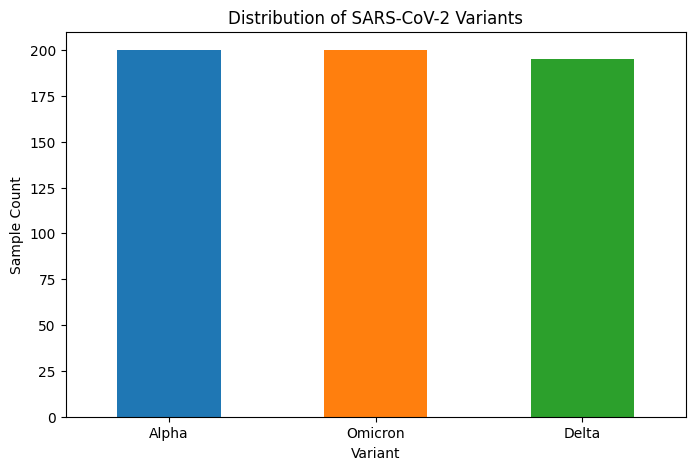

In [3]:
print("Sequence Length Statistics (Pre-cleaning):")
print(df.groupby("variant")["length"].describe())

df_clean = df[(df["length"] >= 1200) & (df["length"] <= 1300)].copy()
print(f"\nRemaining data after length filtering (1200-1300): {len(df_clean)} rows")

plt.figure(figsize=(8, 5))
df_clean['variant'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Distribution of SARS-CoV-2 Variants")
plt.ylabel("Sample Count")
plt.xlabel("Variant")
plt.xticks(rotation=0)
plt.show()

In [4]:
def calculate_mutations(aligned_ref, aligned_query):
    mismatches, gaps = 0, 0
    for r, q in zip(aligned_ref, aligned_query):
        if r == '-' or q == '-':
            gaps += 1
        elif r != q:
            mismatches += 1
    return mismatches, gaps

dataset_ml = []

print("Initiating feature extraction via sequence alignment...")
for variant in ["Alpha", "Delta", "Omicron"]:
    df_variant = df_clean[df_clean["variant"] == variant]
    print(f"Processing {len(df_variant)} sequences for {variant}...")
    
    for _, row in tqdm(df_variant.iterrows(), total=len(df_variant)):
        query_seq = row["sequence"]
        
        score, al_wuhan, al_query = needleman_wunsch_affine(wuhan_seq, query_seq)
        mismatches, gaps = calculate_mutations(al_wuhan, al_query)
        
        dataset_ml.append({
            "id": row["id"],
            "variant": variant,
            "length": row["length"],
            "score_blosum": score,
            "mismatches": mismatches,
            "gap_count": gaps
        })

df_ml = pd.DataFrame(dataset_ml)
output_path = os.path.join(DATA_DIR, "sars_features_extracted.csv")
df_ml.to_csv(output_path, index=False)
print(f"\nFeature matrix saved to {output_path}")

Initiating feature extraction via sequence alignment...
Processing 200 sequences for Alpha...


 16%|▎ | 32/200 [04:03<21:19,  7.61s/it]


KeyboardInterrupt: 

In [ ]:
X = df_ml[["length", "score_blosum", "mismatches", "gap_count"]]
y = df_ml["variant"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
model_svm.fit(X_train_scaled, y_train)
y_pred_svm = model_svm.predict(X_test_scaled)

print("=== CLASSIFICATION EVALUATION ===")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"SVM (RBF) Accuracy    : {accuracy_score(y_test, y_pred_svm):.4f}")

print("\nFeature Importances (Random Forest):")
for col, imp in zip(X.columns, model_rf.feature_importances_):
    print(f"{col:<15}: {imp:.4f}")

In [ ]:
print("=== K-FOLD CROSS VALIDATION (k=5) ===")
X_scaled_full = scaler.fit_transform(X)

cv_scores_rf = cross_val_score(model_rf, X, y, cv=5)
cv_scores_svm = cross_val_score(model_svm, X_scaled_full, y, cv=5)

print(f"Random Forest CV Mean : {cv_scores_rf.mean():.4f} (std: {cv_scores_rf.std():.4f})")
print(f"SVM (RBF) CV Mean     : {cv_scores_svm.mean():.4f} (std: {cv_scores_svm.std():.4f})")

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model_rf.classes_, 
            yticklabels=model_rf.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
model_dir = "../src/backend/model"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(model_rf, os.path.join(model_dir, "sars_rf_model.joblib"))
joblib.dump(model_svm, os.path.join(model_dir, "sars_svm_model.joblib"))
joblib.dump(scaler, os.path.join(model_dir, "sars_scaler.joblib"))

print(f"Models and scaler successfully exported to {model_dir}/")